# Expert Evaluation Overview

This notebook summarizes the expert judgments for the three recovery approaches. It assumes there are two expert annotation files per approach, each with 50 examples.

In [1]:
from pathlib import Path
import json
import os
import time
from collections import Counter, defaultdict

import pandas as pd
from IPython.display import display

EVAL_DIR = None
LLM_CACHE_PATH = None

JUDGMENTS = ["plausible", "mild", "negative"]
JUDGMENT_SCORE = {"negative": 0, "mild": 1, "plausible": 2}
SCORE_JUDGMENT = {score: judgment for judgment, score in JUDGMENT_SCORE.items()}

DEFAULT_LLM_MODEL = os.environ.get("EXPERT_EVAL_LLM_MODEL", "gpt-4.1-mini")
ALLOW_LLM_API_CALLS = False  # Set to True once to create/update the cache.

APPROACH_FILES = {
    "pseudo_label": [
        "audit_sample_cti_rev1.json",
        "audit_sample_cti_rev2.json",
    ],
    "embeddings": [
        "audit_sample_embeddings_rev3.json",
        "audit_sample_embeddings_rev2.json",
    ],
    "hierarchy": [
        "audit_sample_hierarchy_rev3.json",
        "audit_sample_hierarchy_rev1.json",
    ],
}

all_configured_files = [file_name for files in APPROACH_FILES.values() for file_name in files]
eval_dir_candidates = [Path("."), Path("expert_eval"), Path.cwd(), Path.cwd() / "expert_eval", Path.cwd().parent / "expert_eval"]

for candidate in eval_dir_candidates:
    if all((candidate / file_name).exists() for file_name in all_configured_files):
        EVAL_DIR = candidate
        break

if EVAL_DIR is None:
    missing_by_candidate = {
        str(candidate): [file_name for file_name in all_configured_files if not (candidate / file_name).exists()]
        for candidate in eval_dir_candidates
    }
    raise FileNotFoundError(f"Could not find all configured evaluation files. Missing files by candidate: {missing_by_candidate}")

LLM_CACHE_PATH = EVAL_DIR / "llm_judgments_cache.json"

print(f"Using evaluation directory: {EVAL_DIR.resolve()}")
print(f"LLM cache path: {LLM_CACHE_PATH.resolve()}")

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)


Using evaluation directory: C:\Users\SimonettoS\OneDrive - University of Twente\Bureaublad\sentence_to_ttp\sentence_to_ttp_augmentation\expert_eval
LLM cache path: C:\Users\SimonettoS\OneDrive - University of Twente\Bureaublad\sentence_to_ttp\sentence_to_ttp_augmentation\expert_eval\llm_judgments_cache.json


## Load Data

In [2]:
def load_json(path):
    with path.open(encoding="utf-8") as f:
        return json.load(f)


records = []

for approach, files in APPROACH_FILES.items():
    for file_name in files:
        path = EVAL_DIR / file_name
        data = load_json(path)
        expert = "rev1" if "rev1" in file_name else "rev2" if "rev2" in file_name else "rev3" if "rev3" in file_name else "expert_1"

        for item in data:
            records.append(
                {
                    "approach": approach,
                    "expert": expert,
                    "file": file_name,
                    "id": item["id"],
                    "sentence_id": item.get("sentence_id"),
                    "sentence": item.get("sentence"),
                    "label": item.get("label"),
                    "label_description_full": item.get("label_description_full", ""),
                    "judgment": item.get("expert_judgment"),
                    "notes": item.get("notes", ""),
                }
            )

df = pd.DataFrame(records)

print(f"Loaded {len(df)} expert ratings across {df['approach'].nunique()} approaches.")
display(df.head())


Loaded 300 expert ratings across 3 approaches.


,approach,expert,file,id,sentence_id,sentence,label,label_description_full,judgment,notes
0,pseudo_label,rev1,audit_sample_cti_rev1.json,pseu_0001,1847,We suspect1/21/2021 A Deep Dive Into Patchwork...,T1566.001,Adversaries may send spearphishing emails with...,plausible,
1,pseudo_label,rev1,audit_sample_cti_rev1.json,pseu_0002,712,Masquerading: Match Legitim ate Name or Locati...,T1036.005,Adversaries may match or approximate the name ...,plausible,
2,pseudo_label,rev1,audit_sample_cti_rev1.json,pseu_0003,2106,The payload (abbad7acd\xe2\x80\xa6) is an exec...,T1027,Adversaries may attempt to make an executable ...,plausible,
3,pseudo_label,rev1,audit_sample_cti_rev1.json,pseu_0004,1168,System Network Configuration Discovery Okrum c...,T1016,Adversaries may look for details about the net...,plausible,
4,pseudo_label,rev1,audit_sample_cti_rev1.json,pseu_0005,1208,Installer DLL The installer uses UAC bypass te...,T1548.002,Adversaries may bypass UAC mechanisms to eleva...,plausible,


## Per-File Summary

In [3]:
def judgment_summary(group_cols):
    counts = (
        df.groupby(group_cols + ["judgment"])
        .size()
        .unstack(fill_value=0)
        .reindex(columns=JUDGMENTS, fill_value=0)
    )

    counts.columns.name = None
    counts["n"] = counts[JUDGMENTS].sum(axis=1)
    counts["plausible_%"] = counts["plausible"] / counts["n"] * 100
    counts["mild_%"] = counts["mild"] / counts["n"] * 100
    counts["negative_%"] = counts["negative"] / counts["n"] * 100
    counts["acceptable_%"] = (counts["plausible"] + counts["mild"]) / counts["n"] * 100
    counts["weighted_score"] = (counts["plausible"] + 0.5 * counts["mild"]) / counts["n"]

    ordered_cols = [
        "n",
        "plausible",
        "mild",
        "negative",
        "plausible_%",
        "mild_%",
        "negative_%",
        "acceptable_%",
        "weighted_score",
    ]
    return counts[ordered_cols].round(3).reset_index()


per_file = judgment_summary(["approach", "expert", "file"])
display(per_file)

,approach,expert,file,n,plausible,mild,negative,plausible_%,mild_%,negative_%,acceptable_%,weighted_score
0,embeddings,rev2,audit_sample_embeddings_rev2.json,50,26,3,21,52.0,6.0,42.0,58.0,0.55
1,embeddings,rev3,audit_sample_embeddings_rev3.json,50,21,15,14,42.0,30.0,28.0,72.0,0.57
2,hierarchy,rev1,audit_sample_hierarchy_rev1.json,50,20,17,13,40.0,34.0,26.0,74.0,0.57
3,hierarchy,rev3,audit_sample_hierarchy_rev3.json,50,28,17,5,56.0,34.0,10.0,90.0,0.73
4,pseudo_label,rev1,audit_sample_cti_rev1.json,50,37,8,5,74.0,16.0,10.0,90.0,0.82
5,pseudo_label,rev2,audit_sample_cti_rev2.json,50,42,5,3,84.0,10.0,6.0,94.0,0.89


## LLM-Assisted Majority Vote by Approach

Each example now receives a third judgment from an LLM, and the final label is decided by majority vote across:

- expert 1
- expert 2
- the LLM

This removes the optimistic/pessimistic tie-break rule. Because there are now three voters, each example has a strict majority outcome.

To avoid accidental API usage, this notebook reads from `llm_judgments_cache.json` when available. If the cache is missing or incomplete, set `ALLOW_LLM_API_CALLS = True` in the setup cell and re-run this section once to populate the cache.


In [4]:
def example_cache_key(approach, example_id):
    return f"{approach}::{example_id}"


def load_llm_cache(path):
    if not path.exists():
        return {}

    with path.open(encoding="utf-8") as f:
        cache = json.load(f)

    if not isinstance(cache, dict):
        raise ValueError(f"Expected dict-shaped cache in {path}, found {type(cache).__name__}.")

    return cache


def save_llm_cache(cache, path):
    with path.open("w", encoding="utf-8") as f:
        json.dump(cache, f, indent=2, ensure_ascii=False)


def extract_json_object(text):
    start = text.find("{")
    end = text.rfind("}")
    if start == -1 or end == -1 or end < start:
        raise ValueError(f"Could not find JSON object in model response: {text!r}")
    return json.loads(text[start:end + 1])


def build_llm_prompt(example):
    return f"""You are evaluating whether a recovered MITRE ATT&CK technique label is a good match for a sentence.

Return exactly one judgment:
- plausible: the sentence clearly supports the assigned label
- mild: the sentence is somewhat related, but the match is weak, incomplete, or ambiguous
- negative: the sentence does not support the assigned label or points to a different behavior

Evaluate the following example.

Approach: {example['approach']}
Example ID: {example['id']}
Sentence ID: {example.get('sentence_id', '')}
Sentence: {example['sentence']}
Assigned label: {example['label']}
Label description: {example.get('label_description_full', '')}

Respond with JSON only in this format:
{{"judgment": "plausible|mild|negative", "reason": "one short sentence"}}"""


def request_llm_judgment(client, example, model=DEFAULT_LLM_MODEL):
    response = client.responses.create(
        model=model,
        input=build_llm_prompt(example),
    )
    payload = extract_json_object(response.output_text)
    judgment = payload.get("judgment")

    if judgment not in JUDGMENTS:
        raise ValueError(f"Invalid LLM judgment {judgment!r} for {example['approach']}/{example['id']}.")

    return {
        "judgment": judgment,
        "reason": payload.get("reason", "").strip(),
        "model": model,
    }


def aggregate_three_way(expert_judgments, llm_judgment):
    expert_judgments = list(expert_judgments)

    if len(expert_judgments) != 2:
        raise ValueError(f"Expected exactly 2 expert judgments, found {len(expert_judgments)}.")

    vote_counts = Counter(expert_judgments + [llm_judgment])
    final_judgment = max(vote_counts.items(), key=lambda item: (item[1], JUDGMENT_SCORE[item[0]]))[0]

    if expert_judgments[0] == expert_judgments[1] == llm_judgment:
        aggregation_rule = "unanimous"
    elif expert_judgments[0] == expert_judgments[1]:
        aggregation_rule = "experts_outvote_llm"
    else:
        aggregation_rule = "llm_breaks_expert_tie"

    return final_judgment, aggregation_rule


example_df = (
    df.sort_values(["approach", "id", "expert"])
    .drop_duplicates(subset=["approach", "id"])
    .reset_index(drop=True)
)

llm_cache = load_llm_cache(LLM_CACHE_PATH)
missing_examples = []

for example in example_df.to_dict("records"):
    key = example_cache_key(example["approach"], example["id"])
    cached = llm_cache.get(key)

    if not isinstance(cached, dict) or cached.get("judgment") not in JUDGMENTS:
        missing_examples.append(example)

if missing_examples:
    if not ALLOW_LLM_API_CALLS:
        raise RuntimeError(
            f"LLM cache is missing {len(missing_examples)} examples. "
            "Set ALLOW_LLM_API_CALLS = True in the setup cell, ensure OPENAI_API_KEY is configured, "
            "and re-run this cell once to populate the cache."
        )

    from openai import OpenAI

    client = OpenAI()

    for idx, example in enumerate(missing_examples, start=1):
        key = example_cache_key(example["approach"], example["id"])
        llm_cache[key] = request_llm_judgment(client, example)
        save_llm_cache(llm_cache, LLM_CACHE_PATH)

        if idx % 10 == 0 or idx == len(missing_examples):
            print(f"Cached {idx}/{len(missing_examples)} new LLM judgments...")

        time.sleep(0.2)

llm_records = []

for example in example_df.to_dict("records"):
    key = example_cache_key(example["approach"], example["id"])
    cached = llm_cache[key]
    llm_records.append(
        {
            "approach": example["approach"],
            "id": example["id"],
            "llm_judgment": cached["judgment"],
            "llm_reason": cached.get("reason", ""),
            "llm_model": cached.get("model", DEFAULT_LLM_MODEL),
        }
    )

llm_df = pd.DataFrame(llm_records)

aggregate_rows = []

for (approach, example_id), group in df.groupby(["approach", "id"]):
    if len(group) != 2:
        raise ValueError(f"Expected 2 expert judgments for {approach}/{example_id}, found {len(group)}.")

    example = group.sort_values("expert").iloc[0]
    expert_judgments = group.sort_values("expert")["judgment"].tolist()
    llm_judgment = llm_df.loc[(llm_df["approach"] == approach) & (llm_df["id"] == example_id), "llm_judgment"].iloc[0]

    final_judgment, aggregation_rule = aggregate_three_way(expert_judgments, llm_judgment)

    aggregate_rows.append(
        {
            "approach": approach,
            "id": example_id,
            "sentence_id": example["sentence_id"],
            "sentence": example["sentence"],
            "label": example["label"],
            "expert_judgments": " / ".join(expert_judgments),
            "llm_judgment": llm_judgment,
            "all_judgments": " / ".join(expert_judgments + [llm_judgment]),
            "final_judgment": final_judgment,
            "aggregation_rule": aggregation_rule,
        }
    )

aggregate_df = pd.DataFrame(aggregate_rows)

display(aggregate_df.head())

aggregate_counts = (
    aggregate_df.groupby(["approach", "final_judgment"])
    .size()
    .unstack(fill_value=0)
    .reindex(columns=JUDGMENTS, fill_value=0)
)
aggregate_counts.columns.name = None
aggregate_counts["n"] = aggregate_counts[JUDGMENTS].sum(axis=1)
aggregate_counts["plausible_%"] = aggregate_counts["plausible"] / aggregate_counts["n"] * 100
aggregate_counts["mild_%"] = aggregate_counts["mild"] / aggregate_counts["n"] * 100
aggregate_counts["negative_%"] = aggregate_counts["negative"] / aggregate_counts["n"] * 100
aggregate_counts["acceptable_%"] = (aggregate_counts["plausible"] + aggregate_counts["mild"]) / aggregate_counts["n"] * 100
aggregate_counts["weighted_score"] = (aggregate_counts["plausible"] + 0.5 * aggregate_counts["mild"]) / aggregate_counts["n"]

rule_counts = aggregate_df.groupby(["approach", "aggregation_rule"]).size().unstack(fill_value=0)

by_approach = (
    aggregate_counts.reset_index()
    .merge(rule_counts.reset_index(), on="approach", how="left")
    .rename(columns={"n": "aggregated_examples"})
)

for col in ["unanimous", "experts_outvote_llm", "llm_breaks_expert_tie"]:
    if col not in by_approach:
        by_approach[col] = 0

by_approach = by_approach[
    [
        "approach",
        "aggregated_examples",
        "unanimous",
        "experts_outvote_llm",
        "llm_breaks_expert_tie",
        "plausible",
        "mild",
        "negative",
        "plausible_%",
        "mild_%",
        "acceptable_%",
        "negative_%",
        "weighted_score",
    ]
].sort_values(["plausible_%", "acceptable_%"], ascending=False).round(3)

display(by_approach)


,approach,id,sentence_id,sentence,label,expert_judgments,llm_judgment,all_judgments,final_judgment,aggregation_rule
0,embeddings,embe_0001,8120,Kwampirs collects a list of active and listeni...,T1016,plausible / plausible,plausible,plausible / plausible / plausible,plausible,unanimous
1,embeddings,embe_0002,8016,OilRig has used <code>sc query</code> on a vic...,T1082,negative / mild,plausible,negative / mild / plausible,plausible,llm_breaks_expert_tie
2,embeddings,embe_0003,8134,BitPaymer can enumerate existing Windows servi...,T1082,negative / negative,mild,negative / negative / mild,negative,experts_outvote_llm
3,embeddings,embe_0004,8089,SLOTHFULMEDIA can enumerate open ports on a vi...,T1016,plausible / plausible,mild,plausible / plausible / mild,plausible,experts_outvote_llm
4,embeddings,embe_0005,8105,HexEval Loader has a function where the C2 end...,T1082,negative / mild,negative,negative / mild / negative,negative,llm_breaks_expert_tie


,approach,aggregated_examples,unanimous,experts_outvote_llm,llm_breaks_expert_tie,plausible,mild,negative,plausible_%,mild_%,acceptable_%,negative_%,weighted_score
2,pseudo_label,50,35,1,14,45,2,3,90.0,4.0,94.0,6.0,0.92
1,hierarchy,50,18,6,26,29,10,11,58.0,20.0,78.0,22.0,0.68
0,embeddings,50,16,14,20,29,6,15,58.0,12.0,70.0,30.0,0.64


## LLM Tie-Break Cases

These are the examples where the two experts disagreed and the LLM supplied the deciding third vote.


In [5]:
llm_tiebreak_df = aggregate_df[aggregate_df["aggregation_rule"] == "llm_breaks_expert_tie"].copy()

llm_tiebreak_summary = (
    llm_tiebreak_df.groupby(["approach", "final_judgment"])
    .size()
    .unstack(fill_value=0)
    .reindex(columns=JUDGMENTS, fill_value=0)
    .reset_index()
)

print(f"Examples resolved by the LLM tie-break: {len(llm_tiebreak_df)}")
display(llm_tiebreak_summary)
display(
    llm_tiebreak_df[
        [
            "approach",
            "id",
            "label",
            "expert_judgments",
            "llm_judgment",
            "final_judgment",
            "sentence",
        ]
    ]
)


Examples resolved by the LLM tie-break: 60


final_judgment,approach,plausible,mild,negative
0,embeddings,11,4,5
1,hierarchy,15,4,7
2,pseudo_label,11,2,1


,approach,id,label,expert_judgments,llm_judgment,final_judgment,sentence
1,embeddings,embe_0002,T1082,negative / mild,plausible,plausible,OilRig has used <code>sc query</code> on a vic...
4,embeddings,embe_0005,T1082,negative / mild,negative,negative,HexEval Loader has a function where the C2 end...
7,embeddings,embe_0008,T1082,negative / mild,negative,negative,TeamTNT has searched for services such as Alib...
8,embeddings,embe_0009,T1082,negative / plausible,plausible,plausible,Babuk can enumerate all services running on a ...
9,embeddings,embe_0010,T1082,negative / plausible,plausible,plausible,SysUpdate can collect a list of services on a ...
10,embeddings,embe_0011,T1082,negative / mild,mild,mild,WINERACK can enumerate services.
11,embeddings,embe_0012,T1566.001,negative / mild,negative,negative,Use anti-spoofing and email authentication mec...
14,embeddings,embe_0015,T1566.001,plausible / negative,mild,plausible,SideCopy has crafted generic lures for spam ca...
19,embeddings,embe_0020,T1016,negative / plausible,negative,negative,Babuk can use “WNetOpenEnumW” and “WNetEnumRes...
22,embeddings,embe_0023,T1016,plausible / mild,plausible,plausible,Cuba can use the function <code>GetIpNetTable<...


## Visual Comparison

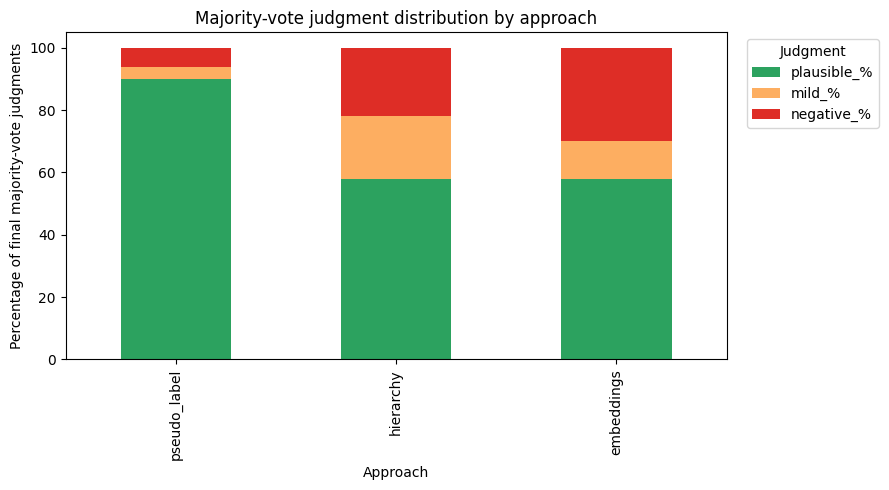

In [6]:
plot_df = by_approach.set_index("approach")[["plausible_%", "mild_%", "negative_%"]]

try:
    import matplotlib.pyplot as plt

    ax = plot_df.plot(
        kind="bar",
        stacked=True,
        figsize=(9, 5),
        color=["#2ca25f", "#fdae61", "#de2d26"],
    )
    ax.set_ylabel("Percentage of final majority-vote judgments")
    ax.set_xlabel("Approach")
    ax.set_title("Majority-vote judgment distribution by approach")
    ax.legend(title="Judgment", bbox_to_anchor=(1.02, 1), loc="upper left")
    ax.figure.tight_layout()
except ImportError:
    print("matplotlib is not installed, so showing the plot source table instead.")
    display(plot_df)


## Expert Agreement

In [7]:
def cohen_kappa(a, b, labels=JUDGMENTS):
    if len(a) != len(b):
        raise ValueError("Both expert judgment lists must have the same length.")

    n = len(a)
    observed = sum(x == y for x, y in zip(a, b)) / n
    counts_a = Counter(a)
    counts_b = Counter(b)
    expected = sum((counts_a[label] / n) * (counts_b[label] / n) for label in labels)

    if expected == 1:
        return 1.0
    return (observed - expected) / (1 - expected)


agreement_rows = []
confusion_matrices = {}

for approach in APPROACH_FILES:
    expert_df = df[df["approach"] == approach]
    wide = expert_df.pivot(index="id", columns="expert", values="judgment")

    if wide.shape[1] != 2:
        raise ValueError(f"Expected exactly two experts for {approach}, found {wide.shape[1]}.")

    expert_a, expert_b = wide.columns.tolist()
    paired = wide.dropna()
    a = paired[expert_a].tolist()
    b = paired[expert_b].tolist()

    agreement_rows.append(
        {
            "approach": approach,
            "expert_a": expert_a,
            "expert_b": expert_b,
            "n": len(paired),
            "exact_agreement": sum(x == y for x, y in zip(a, b)),
            "exact_agreement_%": sum(x == y for x, y in zip(a, b)) / len(paired) * 100,
            "cohen_kappa": cohen_kappa(a, b),
            "both_plausible": sum(x == "plausible" and y == "plausible" for x, y in zip(a, b)),
            "any_negative": sum(x == "negative" or y == "negative" for x, y in zip(a, b)),
            "both_negative": sum(x == "negative" and y == "negative" for x, y in zip(a, b)),
        }
    )

    confusion_matrices[approach] = pd.crosstab(
        paired[expert_a],
        paired[expert_b],
        rownames=[expert_a],
        colnames=[expert_b],
    ).reindex(index=JUDGMENTS, columns=JUDGMENTS, fill_value=0)

agreement = pd.DataFrame(agreement_rows).round(3)
display(agreement)

,approach,expert_a,expert_b,n,exact_agreement,exact_agreement_%,cohen_kappa,both_plausible,any_negative,both_negative
0,pseudo_label,rev1,rev2,50,36,72.0,0.214,34,6,2
1,embeddings,rev2,rev3,50,30,60.0,0.381,18,25,10
2,hierarchy,rev1,rev3,50,24,48.0,0.180,14,14,4


In [8]:
for approach, matrix in confusion_matrices.items():
    print(f"\n{approach}")
    display(matrix)


pseudo_label


rev2,plausible,mild,negative
rev1,,,
plausible,34,2,1
mild,8,0,0
negative,0,3,2



embeddings


rev3,plausible,mild,negative
rev2,,,
plausible,18,5,3
mild,0,2,1
negative,3,8,10



hierarchy


rev3,plausible,mild,negative
rev1,,,
plausible,14,6,0
mild,10,6,1
negative,4,5,4


## Optional: Inspect Examples with Notes or Negative Judgments

In [9]:
with_notes = df[df["notes"].fillna("").str.strip().ne("")]
display(with_notes[["approach", "expert", "id", "label", "judgment", "notes", "sentence"]])

,approach,expert,id,label,judgment,notes,sentence
58,pseudo_label,rev2,pseu_0009,T1552.001,mild,"It also mensions transmitted, so this not only...",This technique is used in scenarios when passw...
62,pseudo_label,rev2,pseu_0013,T1190,mild,The sentence itself is quite generalistic. It ...,Patches for this vulnerability have been avail...
74,pseudo_label,rev2,pseu_0025,T1021.001,mild,While it does describe using RDP the sentence ...,Enables LockBit affiliate actors to remotely c...
76,pseudo_label,rev2,pseu_0027,T1055,mild,"The sentece is quite unclear, but it seems to ...",Detection opportunity 3 Defense Evasion by Pro...
78,pseudo_label,rev2,pseu_0029,T1082,mild,The sentence is quite unclear. It might indeed...,"Possible values are: Windows, Linux. | Value |..."
85,pseudo_label,rev2,pseu_0036,T1557.001,negative,"The sentence is quite generic, and does not re...",In this campaign the Lazarus group demonstrate...
92,pseudo_label,rev2,pseu_0043,T1072,negative,It talks about the APT using malware for their...,"In the last decade, Earth Aughisky has deploye..."
93,pseudo_label,rev2,pseu_0044,T1070.004,negative,It doesn't specify attackers deleting their ac...,Although operating systems have standard comma...
151,embeddings,rev2,embe_0002,T1082,negative,This is information about services more relate...,OilRig has used <code>sc query</code> on a vic...
152,embeddings,rev2,embe_0003,T1082,negative,This is information about services more relate...,BitPaymer can enumerate existing Windows servi...


In [10]:
negative_examples = aggregate_df[aggregate_df["final_judgment"] == "negative"]
display(
    negative_examples[
        [
            "approach",
            "id",
            "label",
            "expert_judgments",
            "llm_judgment",
            "all_judgments",
            "final_judgment",
            "aggregation_rule",
            "sentence",
        ]
    ]
)


,approach,id,label,expert_judgments,llm_judgment,all_judgments,final_judgment,aggregation_rule,sentence
2,embeddings,embe_0003,T1082,negative / negative,mild,negative / negative / mild,negative,experts_outvote_llm,BitPaymer can enumerate existing Windows servi...
4,embeddings,embe_0005,T1082,negative / mild,negative,negative / mild / negative,negative,llm_breaks_expert_tie,HexEval Loader has a function where the C2 end...
7,embeddings,embe_0008,T1082,negative / mild,negative,negative / mild / negative,negative,llm_breaks_expert_tie,TeamTNT has searched for services such as Alib...
11,embeddings,embe_0012,T1566.001,negative / mild,negative,negative / mild / negative,negative,llm_breaks_expert_tie,Use anti-spoofing and email authentication mec...
15,embeddings,embe_0016,T1082,negative / negative,negative,negative / negative / negative,negative,unanimous,Adversaries may try to gather information abou...
19,embeddings,embe_0020,T1016,negative / plausible,negative,negative / plausible / negative,negative,llm_breaks_expert_tie,Babuk can use “WNetOpenEnumW” and “WNetEnumRes...
21,embeddings,embe_0022,T1082,negative / negative,negative,negative / negative / negative,negative,unanimous,SideCopy has identified the country location o...
29,embeddings,embe_0030,T1082,negative / negative,mild,negative / negative / mild,negative,experts_outvote_llm,InvisiMole can obtain running services on the ...
38,embeddings,embe_0039,T1082,negative / negative,mild,negative / negative / mild,negative,experts_outvote_llm,Sykipot may use <code>net start</code> to disp...
40,embeddings,embe_0041,T1082,negative / negative,negative,negative / negative / negative,negative,unanimous,Cuckoo Stealer can determine the geographical ...
